# Notebook 3 - Despliegue del Modelo con Streamlit
## Minería de Datos en Python - Analítica de Datos UPB 2026

**Autores:** Juan David Acevedo - Diego A. Martinez

---

## Objetivo del Notebook

Desplegar el modelo XGBoost hiperparametrizado (entrenado en el Notebook 2) mediante una **interfaz gráfica interactiva** desarrollada con **Streamlit**. La aplicación permite a un usuario final:

1. Ingresar las características de un beneficiario (sexo, nivel educativo, ocupación, etc.).
2. Recibir la **predicción del valor del subsidio** que probablemente recibiría.
3. Visualizar las **variables más importantes** del modelo.
4. Explorar estadísticas del dataset de entrenamiento.

---

## Estructura del despliegue

```
proyecto_mineria/
├── app/                       # Aplicación Streamlit
│   └── app.py                 # Código principal
├── models/                    # Modelos entrenados
│   ├── xgb_mejor_modelo.pkl   # Pipeline XGBoost
│   └── modelo_info.pkl        # Metadatos
├── data/                      # Datos
│   ├── datos_colombia.csv     # Dataset original
│   └── dataset_procesado.csv  # Dataset limpio
└── notebooks/
    └── 03_Despliegue_Streamlit.ipynb  # Este notebook
```

## 1. Código de la Aplicación Streamlit

El archivo `app/app.py` contiene la aplicación completa. A continuación se describe su estructura:

```python
# app/app.py (extracto)
import os, joblib, pandas as pd, numpy as np
import streamlit as st
import matplotlib.pyplot as plt

st.set_page_config(page_title='Predicción Subsidios', page_icon='🏠', layout='wide')

# Cargar modelo entrenado
modelo = joblib.load('../models/xgb_mejor_modelo.pkl')
info   = joblib.load('../models/modelo_info.pkl')

# Formulario en sidebar
input_df = {}
for feature in info['features']:
    opciones = sorted(info['categorias_unicas'][feature])
    input_df[feature] = st.sidebar.selectbox(feature, opciones)
input_df = pd.DataFrame([input_df])

# Botón de predicción
if st.button('Predecir valor del subsidio', type='primary'):
    prediccion = modelo.predict(input_df)[0]
    st.success(f'Valor estimado del subsidio: ${prediccion:,.0f} COP')

# Gráfico de importancia
xgb_model = modelo.named_steps['modelo']
encoder = modelo.named_steps['pre']
importancias = xgb_model.feature_importances_
# ... gráfico de barras horizontal
```

**Archivo completo:** ver `app/app.py` en el repositorio.

## 2. Verificación del Modelo Cargado

Antes de ejecutar la app, verificamos que el modelo guardado en el Notebook 2 se pueda cargar y que las predicciones funcionen correctamente.

In [1]:
import joblib
import pandas as pd
import numpy as np

# Cargar modelo y metadatos
modelo = joblib.load('../models/xgb_mejor_modelo.pkl')
info = joblib.load('../models/modelo_info.pkl')

print(f"Modelo cargado: {type(modelo.named_steps['modelo']).__name__}")
print(f"Preprocesador: {type(modelo.named_steps['pre']).__name__}")
print(f"\nFeatures esperadas ({len(info['features'])}):")
for f in info['features']:
    n_cat = len(info['categorias_unicas'][f])
    print(f"  - {f} ({n_cat} categorías)")

print(f"\nRendimiento reportado (test):")
print(f"  RMSE: ${info['rmse_test']:,.0f} COP")
print(f"  MAE:  ${info['mae_test']:,.0f} COP")
print(f"  R²:   {info['r2_test']:.4f}")


Modelo cargado: XGBRegressor
Preprocesador: ColumnTransformer

Features esperadas (12):
  - TIPO DE MEJORAMIENTO (7 categorías)
  - INGRESOS MENSUALES (5 categorías)
  - LOCALIDAD (4 categorías)
  - SECTOR (4 categorías)
  - CICLO DE VIDA (4 categorías)
  - GRUPO POBLACIONAL (6 categorías)
  - ENTIDAD DISTRITAL QUE ASIGNA EL SUBSIDIO (2 categorías)
  - NIVEL EDUCATIVO (9 categorías)
  - SEXO (2 categorías)
  - ESTADO CIVIL (6 categorías)
  - OCUPACIÓN (9 categorías)
  - ÉTNICO (5 categorías)

Rendimiento reportado (test):
  RMSE: $1,593,281 COP
  MAE:  $970,260 COP
  R²:   0.7896


In [2]:
# Prueba de predicción con un perfil de beneficiario
perfil_prueba = pd.DataFrame([{
    'SEXO': 'Mujer',
    'NIVEL EDUCATIVO': 'Básica primaria (1.o - 5.o)',
    'ESTADO CIVIL': 'Casado(a)',
    'OCUPACIÓN': 'Ama de Casa/Cuidador',
    'INGRESOS MENSUALES': 'Menor a 1 SMMLV',
    'GRUPO POBLACIONAL': 'Ninguno',
    'ÉTNICO': 'Ninguno',
    'CICLO DE VIDA': 'ADULTEZ (29-59)',
    'LOCALIDAD': 'Localidad 2 - Virgen y Turistica',
    'SECTOR': 'URBANO',
    'ENTIDAD DISTRITAL QUE ASIGNA EL SUBSIDIO': 'CORVIVIENDA',
    'TIPO DE MEJORAMIENTO': 'SANEAMIENTO BÁSICO'
}])

print("Perfil del beneficiario de prueba:")
print(perfil_prueba.T)

prediccion = modelo.predict(perfil_prueba)[0]
print(f"\n➡️  Predicción del valor del subsidio: ${prediccion:,.0f} COP")


Perfil del beneficiario de prueba:
                                                                         0
SEXO                                                                 Mujer
NIVEL EDUCATIVO                                Básica primaria (1.o - 5.o)
ESTADO CIVIL                                                     Casado(a)
OCUPACIÓN                                             Ama de Casa/Cuidador
INGRESOS MENSUALES                                         Menor a 1 SMMLV
GRUPO POBLACIONAL                                                  Ninguno
ÉTNICO                                                             Ninguno
CICLO DE VIDA                                              ADULTEZ (29-59)
LOCALIDAD                                 Localidad 2 - Virgen y Turistica
SECTOR                                                              URBANO
ENTIDAD DISTRITAL QUE ASIGNA EL SUBSIDIO                       CORVIVIENDA
TIPO DE MEJORAMIENTO                                    SANEAMIEN

In [3]:
# Verificar que el archivo app.py existe
import os
app_path = '../app/app.py'
if os.path.exists(app_path):
    print(f"✓ app.py encontrado: {app_path}")
    print(f"  Tamaño: {os.path.getsize(app_path):,} bytes")
    print(f"\nPrimeras 30 líneas del archivo:")
    with open(app_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f.readlines()[:30], 1):
            print(f"  {i:3d} | {line.rstrip()}")
else:
    print("✗ app.py NO encontrado")


✓ app.py encontrado: ../app/app.py
  Tamaño: 3,677 bytes

Primeras 30 líneas del archivo:
    1 | """
    2 | App Streamlit para predicción de subsidios de vivienda.
    3 | Ejecutar con: streamlit run app/app.py
    4 | """
    5 | import os
    6 | import joblib
    7 | import pandas as pd
    8 | import numpy as np
    9 | import streamlit as st
   10 | import matplotlib.pyplot as plt
   11 | 
   12 | # Configuración de página
   13 | st.set_page_config(
   14 |     page_title="Predicción Subsidios de Vivienda",
   15 |     page_icon="🏠",
   16 |     layout="wide"
   17 | )
   18 | 
   19 | # Ruta a los modelos
   20 | MODELOS_DIR = os.path.join(os.path.dirname(__file__), '..', 'models')
   21 | MODEL_PATH = os.path.join(MODELOS_DIR, 'xgb_mejor_modelo.pkl')
   22 | INFO_PATH = os.path.join(MODELOS_DIR, 'modelo_info.pkl')
   23 | 
   24 | 
   25 | @st.cache_resource
   26 | def cargar_modelo():
   27 |     modelo = joblib.load(MODEL_PATH)
   28 |     info = joblib.load(INFO_PATH)
   

## 3. Ejecución de la Aplicación

Para ejecutar la aplicación localmente, abre una terminal en la carpeta del proyecto y ejecuta:

```bash
cd proyecto_mineria
streamlit run app/app.py
```

Streamlit iniciará un servidor local en `http://localhost:8501` y abrirá automáticamente el navegador con la interfaz interactiva.

## 4. Captura de Pantalla del Despliegue

A continuación se inicia la aplicación Streamlit en background, se captura una imagen de la interfaz con Playwright y se guarda como `figuras/10_streamlit_despliegue.png`.

In [4]:
# 4.1 Lanzamiento de la app + captura de pantalla
# Como Streamlit y Playwright requieren su propio event loop, la captura se hace
# desde un script standalone (scripts/captura_streamlit.py). A continuación lo ejecutamos:
import subprocess
resultado = subprocess.run(
    ['python', '/home/z/my-project/scripts/captura_streamlit.py'],
    capture_output=True, text=True, timeout=120
)
print(resultado.stdout)
if resultado.returncode != 0:
    print('STDERR:', resultado.stderr[-500:])


[1/4] Iniciando Streamlit...
      PID=2732, esperando 18s para arranque completo...
      Streamlit listo.
[2/4] Capturando pantalla con Playwright...
      ✓ Captura guardada: /home/z/my-project/proyecto_mineria/figuras/10_streamlit_despliegue.png
[3/4] Deteniendo Streamlit...
      Streamlit detenido correctamente.
[4/4] Verificando...
      ✓ Captura creada: /home/z/my-project/proyecto_mineria/figuras/10_streamlit_despliegue.png (93.7 KB)



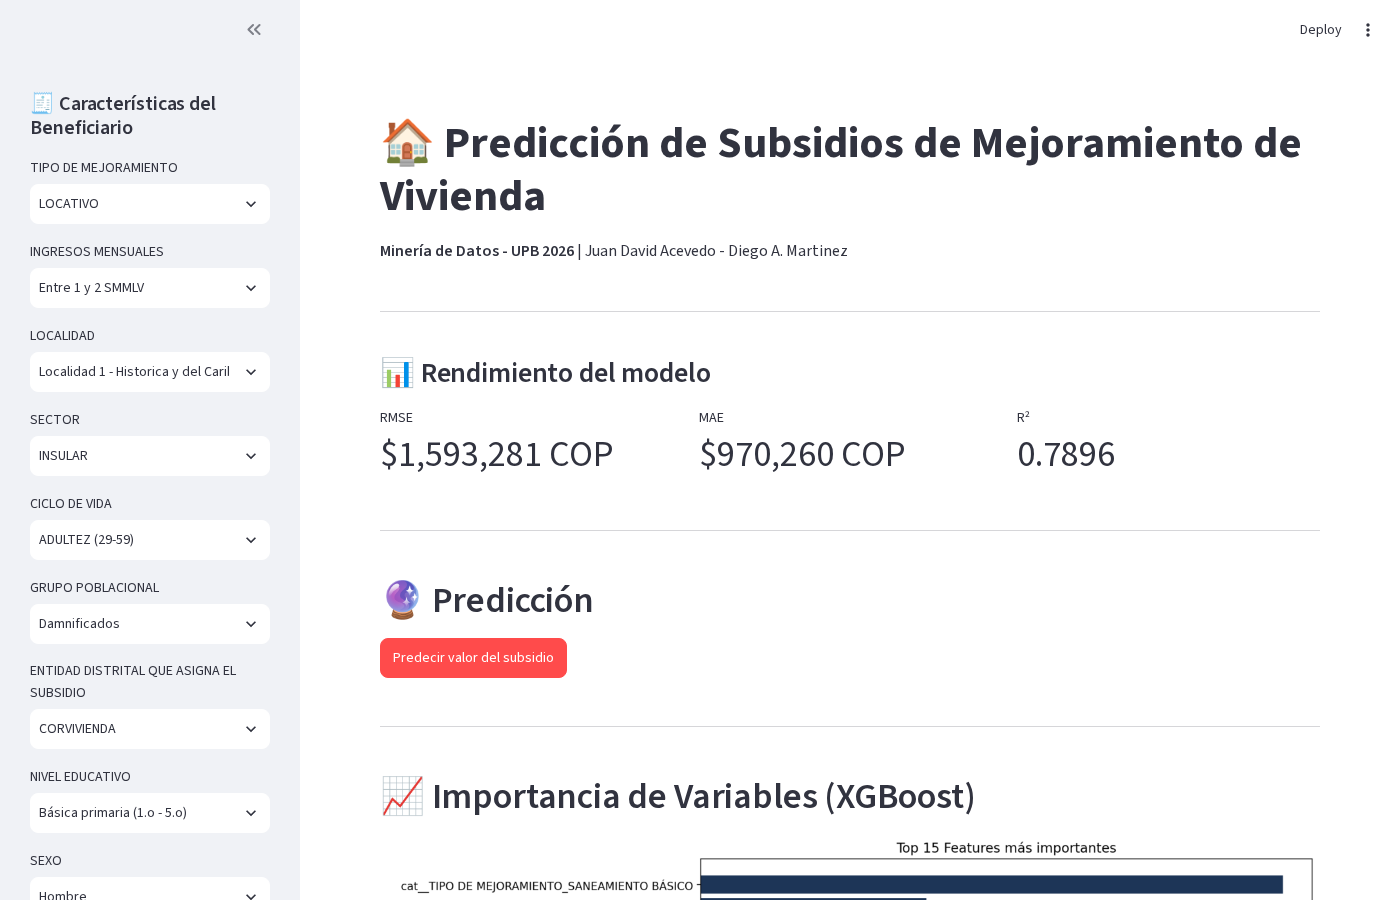


Captura guardada en: ../figuras/10_streamlit_despliegue.png
Tamaño: 93.7 KB


In [5]:
# 4.2 Mostrar la captura en el notebook
from IPython.display import Image, display
import os
captura_path = '../figuras/10_streamlit_despliegue.png'
if os.path.exists(captura_path):
    display(Image(filename=captura_path))
    print(f'\nCaptura guardada en: {captura_path}')
    print(f'Tamaño: {os.path.getsize(captura_path)/1024:.1f} KB')
else:
    print('Captura no disponible.')


## 5. Conclusiones del Despliegue

### Funcionalidades de la App

1. **Predicción interactiva:** el usuario selecciona las características del beneficiario en el sidebar y obtiene la predicción del valor del subsidio con un click.

2. **Visualización del rendimiento:** métricas RMSE, MAE y R² visibles para dar contexto sobre la confiabilidad del modelo.

3. **Importancia de variables:** gráfico de barras que muestra las 15 features más importantes según XGBoost, permitiendo interpretabilidad.

4. **Estadísticas del dataset:** tabla descriptiva del dataset de entrenamiento para contextualizar los rangos esperados del target.

### Cómo ejecutar localmente

```bash
# 1. Clonar el repositorio
git clone https://github.com/<usuario>/mineria-datos-upb-2026.git
cd mineria-datos-upb-2026

# 2. Instalar dependencias
pip install -r requirements.txt

# 3. Ejecutar la app
streamlit run app/app.py
```

### Estructura final del proyecto

```
mineria-datos-upb-2026/
├── README.md
├── requirements.txt
├── .gitignore
├── data/
│   ├── datos_colombia.csv
│   └── dataset_procesado.csv
├── notebooks/
│   ├── 01_EDA_Seleccion_Factores.ipynb
│   ├── 02_Modelado_Predictivo.ipynb
│   └── 03_Despliegue_Streamlit.ipynb
├── models/
│   ├── xgb_mejor_modelo.pkl
│   └── modelo_info.pkl
├── app/
│   └── app.py
└── figuras/
    ├── 01_distribucion_target.png
    ├── ... (todas las figuras)
    └── 10_streamlit_despliegue.png
```